## Text to Image Model

The code below uses a conditional diffusion model to generate images based on a text prompt.

This diffusion model was trained from scratch and is light (100MM params) and trained on only 1 million images.

Note that this notebook does **not** read or write anything to your machine nor does it need any access to google drive or outside sources. All the downloads happen within this notebook and once you close it, it will all go gone poof!

- Author: Alexandru Papiu
- Email: alexpapiu@gmail.com
- To see more details on the code and model training go to the following [Github Repo](https://github.com/apapiu/transformer_latent_diffusion/edit/main/README.md)

Example Generations:

<img width="800" alt="image" src="https://github.com/apapiu/transformer_latent_diffusion/assets/13619417/4bbb9a17-5dd5-416f-8271-3c8d157fc4bd">

### Run this to install - Should take about 1 minute.


In [1]:
%%capture
!pip install git+https://github.com/apapiu/transformer_latent_diffusion.git@legacy_dh_order

from tld.diffusion import DiffusionGenerator, DiffusionTransformer
from tld.configs import LTDConfig, DenoiserConfig, TrainConfig, DenoiserLoad
import torch

denoiser_cfg = DenoiserConfig(image_size = 32,
               noise_embed_dims = 256,
               patch_size = 2,
               embed_dim = 768,
               dropout = 0,
               n_layers = 12,
               text_emb_size = 768)

denoiser_load = DenoiserLoad(**{'dtype': torch.float32,
  'file_url': 'https://huggingface.co/apapiu/small_ldt/resolve/main/state_dict_378000.pth',
  'local_filename': 'state_dict_378000.pth'})


cfg = LTDConfig(denoiser_cfg=denoiser_cfg, denoiser_load=denoiser_load)
diffusion_transformer = DiffusionTransformer(cfg)

## Image Generator:

100%|██████████| 5/5 [00:00<00:00, 35.53it/s]


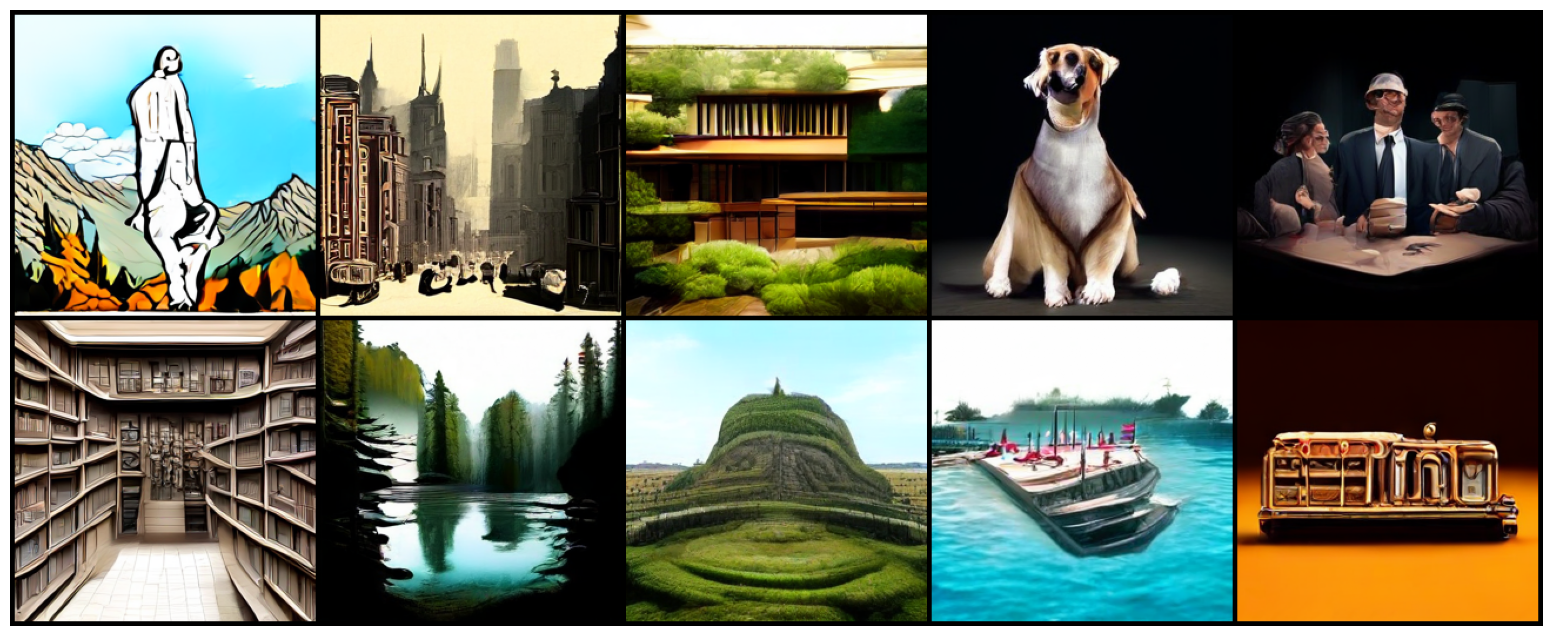

In [17]:
import matplotlib.pyplot as plt


prompts = [
    "Cerro el Plomo en santiago pintado por pablo picasso",
    "Centro de santiago en 1930",
    "Una planta rara en una casa de frank lloyd wright",
    "un perro vestido de frac, atendiendo a una ópera",
    "una reunión de negocios de payasos",
    "una tienda de juguentes enorme y laberíntica de mc escher",
    "un río rodeado de montañas y bosques",
    "una ciudad antigua construida alrededor de un monumento natural",
    "una batalla naval estilo waterloo entre barcos de juguete en una piscina de un parque",
    "un tren en miniatura de juguete al cual están asaltando bándalos de estilo western"
]


from torchvision.transforms import ToTensor

#img grid
seed = 11
imagenes = []

total_compute_time = 0

for i, prompt in enumerate(prompts):

    img = diffusion_transformer.generate_image_from_text(
        prompt=prompt,
        class_guidance=10,
        n_iter=6,
        num_imgs=1,
        seed=seed
    )

    img.save(f"img_{i}.png")

    # Convertir PIL -> Tensor [C,H,W] en rango [0,1]
    imagenes.append(ToTensor()(img))

grid = vutils.make_grid(
    imagenes,
    nrow=5,
    padding=4
)

grid_np = grid.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(20,8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

## Clip Interpolation:
The model will generate images conditioned on a linear interpolation between the text embedding for prompt 1 and the text embedding for prompt 2 using the same seed.

100%|██████████| 19/19 [00:04<00:00,  3.86it/s]


Images Generated. They will shortly output below.


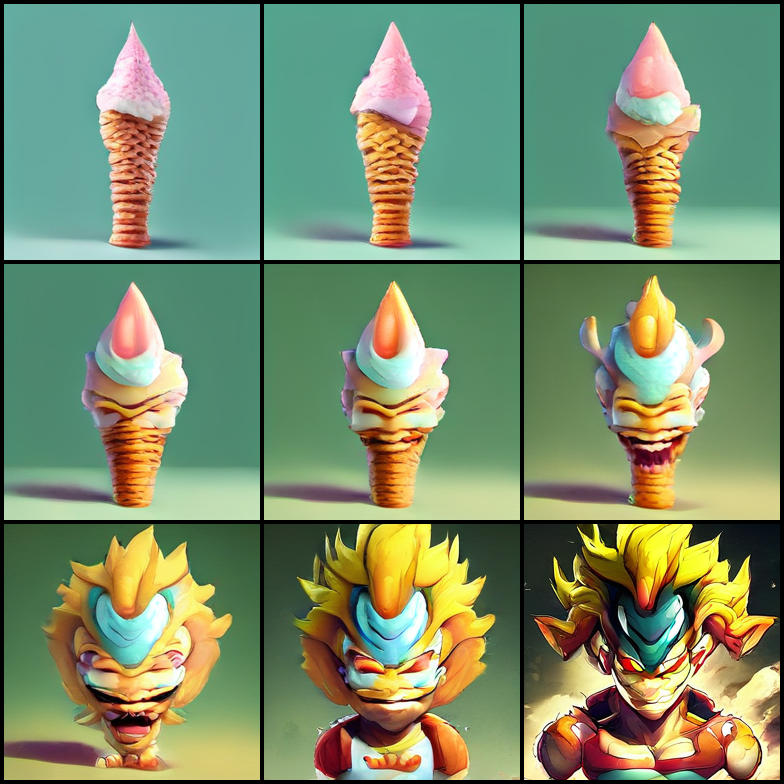

In [3]:
import numpy as np
from tld.diffusion import encode_text
import torchvision.transforms as transforms

to_pil = transforms.ToPILImage()
import torchvision.utils as vutils


prompt1 = "an ice cream cone" #@param {type:"string"}
prompt2 = "dragon ball-z" #@param {type:"string"}
class_guidance = 7 #@param {type:"slider", min:0, max:15, step:0.5}
n_iter = 20 #@param {type:"slider", min:0, max:100, step:1}
num_imgs = 9 #@param {type:"slider", min:1, max:36, step:1}
img_size = 32
seed = 9 #@param{}
nrow = int(np.sqrt(num_imgs))


gen = torch.Generator()
gen.manual_seed(seed)
seeds = torch.randn(1,4,32,32, generator=gen).repeat(num_imgs,1,1,1)
wws = [0, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 1]

cur_prompts = [prompt]*num_imgs

enc2 = encode_text([prompt1], diffusion_transformer.clip_model)
enc1 = encode_text([prompt2], diffusion_transformer.clip_model)

labels = encode_text(cur_prompts, diffusion_transformer.clip_model)
labels = torch.cat([enc1*w+enc2*(1-w) for w in wws], 0)
out, out_latent = diffusion_transformer.diffuser.generate(labels=labels,
                                    seeds=seeds,
                                    num_imgs=num_imgs,
                                    class_guidance=class_guidance,
                                    seed=seed,
                                    n_iter=n_iter,
                                    exponent=1,
                                    sharp_f=0.15,
                                        )

out = to_pil((vutils.make_grid((out+1)/2, nrow=nrow, padding=4)).float().clip(0, 1))

out.save(f'{prompt}_cfg:{class_guidance}_seed:{seed}.png')

print("Images Generated. They will shortly output below.")

out
